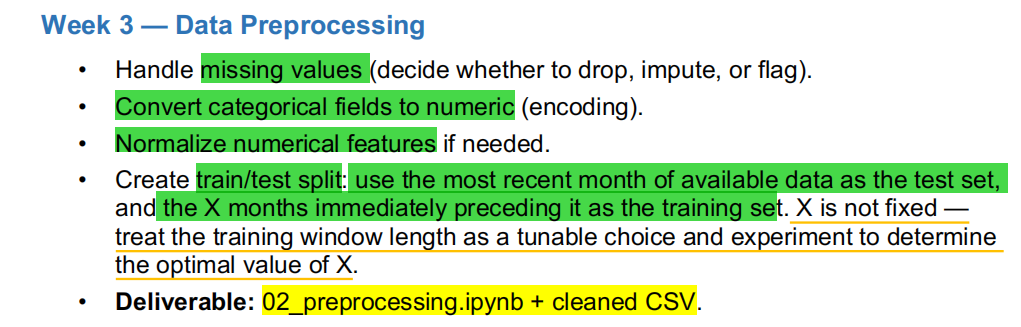

In [315]:
import pandas as pd
import glob
import os
import numpy as np
path = r"C:\Users\23035\OneDrive\Desktop\Internship\dataset"
files = glob.glob(os.path.join(path, "*.csv"))
dfs = []
for f in files:
    data_month=pd.read_csv(f)
    date_ym=pd.to_datetime(os.path.basename(f).split('.')[0][-6:],format="%Y%m")
    data_month['date_ym']=date_ym
    dfs.append(data_month)
dataset_total_last6 = pd.concat(dfs)
    

C:\Users\23035\AppData\Local\Temp\ipykernel_58688\3968008123.py:9: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  data_month=pd.read_csv(f)


# Handle missing values and invalid values

In [316]:
dataset_total_last6_drop= dataset_total_last6.loc[:,dataset_total_last6.isna().mean() < 0.1]
dataset_total_last6_drop.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 124404 entries, 0 to 23259
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   BuyerAgentAOR             118347 non-null  object        
 1   ListAgentAOR              124358 non-null  object        
 2   ViewYN                    112237 non-null  object        
 3   OriginalListPrice         124042 non-null  float64       
 4   ListingKey                124404 non-null  int64         
 5   ListAgentEmail            124134 non-null  object        
 6   CloseDate                 124404 non-null  object        
 7   ClosePrice                124403 non-null  float64       
 8   ListAgentFirstName        123903 non-null  object        
 9   ListAgentLastName         124400 non-null  object        
 10  Latitude                  124378 non-null  float64       
 11  Longitude                 124378 non-null  float64       
 12  Unp

In [317]:
# unreasonable value
dataset_total_last6_drop["ClosePrice"] = dataset_total_last6_drop["ClosePrice"].replace(0, np.nan)
dataset_total_last6_drop["OriginalListPrice"] = dataset_total_last6_drop["ClosePrice"].replace(0, np.nan)
dataset_total_last6_drop["ListPrice"] = dataset_total_last6_drop["ClosePrice"].replace(0, np.nan)
dataset_total_last6_drop["LotSizeSquareFeet"] = dataset_total_last6_drop["LotSizeSquareFeet"].replace(0, np.nan)
dataset_total_last6_drop["LotSizeAcres"] = dataset_total_last6_drop["LotSizeAcres"].replace(0, np.nan)
dataset_total_last6_drop["LivingArea"] = dataset_total_last6_drop["LotSizeSquareFeet"].replace(0, np.nan)

dataset_total_last6_drop.info()

C:\Users\23035\AppData\Local\Temp\ipykernel_58688\3722965492.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_total_last6_drop["ClosePrice"] = dataset_total_last6_drop["ClosePrice"].replace(0, np.nan)
C:\Users\23035\AppData\Local\Temp\ipykernel_58688\3722965492.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_total_last6_drop["OriginalListPrice"] = dataset_total_last6_drop["ClosePrice"].replace(0, np.nan)
C:\Users\23035\AppData\Local\Temp\ipykernel_58688\3722965492.py:4: SettingWithCop

<class 'pandas.core.frame.DataFrame'>
Int64Index: 124404 entries, 0 to 23259
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   BuyerAgentAOR             118347 non-null  object        
 1   ListAgentAOR              124358 non-null  object        
 2   ViewYN                    112237 non-null  object        
 3   OriginalListPrice         124394 non-null  float64       
 4   ListingKey                124404 non-null  int64         
 5   ListAgentEmail            124134 non-null  object        
 6   CloseDate                 124404 non-null  object        
 7   ClosePrice                124394 non-null  float64       
 8   ListAgentFirstName        123903 non-null  object        
 9   ListAgentLastName         124400 non-null  object        
 10  Latitude                  124378 non-null  float64       
 11  Longitude                 124378 non-null  float64       
 12  Unp

In [318]:
missing = dataset_total_last6_drop.isna().astype(int)
missing_corr = missing.corr()
missing_corr

,BuyerAgentAOR,ListAgentAOR,ViewYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,...,BedroomsTotal,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate,StateOrProvince,FireplaceYN,LotSizeArea,PostalCode,LotSizeSquareFeet,date_ym
BuyerAgentAOR,1.000000,0.063644,0.043708,-0.002028,NaN,0.021553,NaN,-0.002028,0.015102,-0.001283,...,-0.013859,NaN,-0.008713,0.002810,NaN,-0.006006,0.025445,0.003196,0.026114,NaN
ListAgentAOR,0.063644,1.000000,0.014781,-0.000172,NaN,-0.000897,NaN,-0.000172,-0.001223,-0.000109,...,-0.005108,NaN,-0.002833,-0.000250,NaN,0.010480,-0.005766,-0.000313,-0.006505,NaN
ViewYN,0.043708,0.014781,1.000000,-0.002952,NaN,-0.014192,NaN,-0.002952,-0.017945,-0.001867,...,0.242317,NaN,-0.046059,0.039464,NaN,0.313275,-0.008415,-0.003701,0.030311,NaN
OriginalListPrice,-0.002028,-0.000172,-0.002952,1.000000,NaN,-0.000418,NaN,1.000000,-0.000570,-0.000051,...,-0.002381,NaN,0.004898,-0.000117,NaN,-0.002754,0.000571,-0.000146,-0.000079,NaN
ListingKey,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ListAgentEmail,0.021553,-0.000897,-0.014192,-0.000418,NaN,1.000000,NaN,-0.000418,-0.000238,0.030198,...,-0.001941,NaN,0.012299,0.025986,NaN,-0.003246,-0.012727,-0.000760,-0.011221,NaN
CloseDate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ClosePrice,-0.002028,-0.000172,-0.002952,1.000000,NaN,-0.000418,NaN,1.000000,-0.000570,-0.000051,...,-0.002381,NaN,0.004898,-0.000117,NaN,-0.002754,0.000571,-0.000146,-0.000079,NaN
ListAgentFirstName,0.015102,-0.001223,-0.017945,-0.000570,NaN,-0.000238,NaN,-0.000570,1.000000,0.022023,...,-0.006143,NaN,-0.008486,-0.000826,NaN,-0.004607,0.006310,-0.001036,0.001492,NaN
ListAgentLastName,-0.001283,-0.000109,-0.001867,-0.000051,NaN,0.030198,NaN,-0.000051,0.022023,1.000000,...,-0.001506,NaN,0.008997,-0.000074,NaN,-0.001742,-0.001700,-0.000092,-0.001918,NaN


In [319]:
dataset_total_last6_drop = dataset_total_last6_drop.drop(columns=[
    "ListAgentEmail",
    "ListingKey",
    "BuyerAgentMlsId",
    "ListAgentEmail",
    "ListingKeyNumeric",
    "PostalCode","UnparsedAddress"
])

In [320]:
# drop nan values
dataset_total_last6_drop=dataset_total_last6_drop.dropna()
dataset_total_last6_drop.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 83444 entries, 2 to 23256
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   BuyerAgentAOR             83444 non-null  object        
 1   ListAgentAOR              83444 non-null  object        
 2   ViewYN                    83444 non-null  object        
 3   OriginalListPrice         83444 non-null  float64       
 4   CloseDate                 83444 non-null  object        
 5   ClosePrice                83444 non-null  float64       
 6   ListAgentFirstName        83444 non-null  object        
 7   ListAgentLastName         83444 non-null  object        
 8   Latitude                  83444 non-null  float64       
 9   Longitude                 83444 non-null  float64       
 10  PropertyType              83444 non-null  object        
 11  LivingArea                83444 non-null  float64       
 12  ListPrice         

# Convert datatype

In [321]:
# yes or no
yn_map = {"Yes": 1, "No": 0}
tf_map = {True: 1, False: 0}
dataset_total_last6_drop["ViewYN"]=dataset_total_last6_drop["ViewYN"].map(tf_map)
dataset_total_last6_drop["FireplaceYN"]=dataset_total_last6_drop["FireplaceYN"].map(yn_map)
# date time    
date_cols = ["CloseDate", "ContractStatusChangeDate", "PurchaseContractDate", "ListingContractDate"]
for col in date_cols:
        dataset_total_last6_drop[col] = dataset_total_last6_drop[col].astype("datetime64[ns]")

In [322]:
dataset_total_last6_drop.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 83444 entries, 2 to 23256
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   BuyerAgentAOR             83444 non-null  object        
 1   ListAgentAOR              83444 non-null  object        
 2   ViewYN                    83444 non-null  int64         
 3   OriginalListPrice         83444 non-null  float64       
 4   CloseDate                 83444 non-null  datetime64[ns]
 5   ClosePrice                83444 non-null  float64       
 6   ListAgentFirstName        83444 non-null  object        
 7   ListAgentLastName         83444 non-null  object        
 8   Latitude                  83444 non-null  float64       
 9   Longitude                 83444 non-null  float64       
 10  PropertyType              83444 non-null  object        
 11  LivingArea                83444 non-null  float64       
 12  ListPrice         

In [323]:
from sklearn.preprocessing import LabelEncoder
print(dataset_total_last6_drop["BuyerAgentAOR"].value_counts())
le = LabelEncoder()
dataset_total_last6_drop["BuyerAgentAOR"] = le.fit_transform(dataset_total_last6_drop["BuyerAgentAOR"].astype(str))

OrangeCounty                           9362
PacificWest                            6531
Southland                              6364
BeverlyHillsGreaterLa                  6202
CitrusValley                           4344
Mlslistings                            3519
SanDiego                               3511
SouthwestRiversideCounty               3289
TheInlandGateway                       3275
Mrmls                                  3007
InlandValleys                          2745
SouthBay                               2432
CaliforniaDesert                       2325
Downey                                 1982
NorthSanDiegoCounty                    1951
TriCounties                            1731
WestSanGabrielValley                   1512
PacificSouthwest                       1450
Newport                                1207
VenturaCoastal                         1204
Conejo                                 1121
PasadenaFoothills                      1098
Glendale                        

In [324]:
print(dataset_total_last6_drop["ListAgentAOR"].value_counts())
le = LabelEncoder()
dataset_total_last6_drop["BuyerAgentAOR"] = le.fit_transform(dataset_total_last6_drop["BuyerAgentAOR"].astype(str))

OrangeCounty                           9967
Southland                              7386
PacificWest                            6888
BeverlyHillsGreaterLa                  5342
CitrusValley                           4614
SouthwestRiversideCounty               4050
TheInlandGateway                       3607
Mlslistings                            3404
InlandValleys                          2996
SouthBay                               2682
NorthSanDiegoCounty                    2573
SanDiego                               2557
CaliforniaDesert                       2166
TriCounties                            1885
PacificSouthwest                       1682
Downey                                 1643
WestSanGabrielValley                   1628
Newport                                1269
HighDesert                             1172
Arcadia                                1118
VenturaCoastal                         1098
Glendale                               1054
Conejo                          

In [325]:
print(dataset_total_last6_drop["PropertyType"].value_counts())
dataset_total_last6_drop = pd.get_dummies( dataset_total_last6_drop, columns=["PropertyType"], drop_first=True)

Residential           61165
ResidentialLease      22268
ManufacturedInPark       11
Name: PropertyType, dtype: int64


In [326]:
print(dataset_total_last6_drop["PropertySubType"].value_counts())
le = LabelEncoder()
dataset_total_last6_drop["PropertySubType"] = le.fit_transform(dataset_total_last6_drop["PropertySubType"].astype(str))

SingleFamilyResidence    60089
Condominium              12398
Townhouse                 4375
Apartment                 2477
Duplex                    1509
ManufacturedOnLand        1102
Triplex                    450
Quadruplex                 363
StockCooperative           227
Cabin                      115
MixedUse                    90
Studio                      88
RoomingHouse                85
MobileHome                  34
OwnYourOwn                  17
Loft                        13
ManufacturedHome             5
CoOwnership                  3
BoatSlip                     2
Timeshare                    1
Farm                         1
Name: PropertySubType, dtype: int64


In [327]:
print(dataset_total_last6_drop["BuyerOfficeAOR"].value_counts())
le = LabelEncoder()
dataset_total_last6_drop["BuyerOfficeAOR"] = le.fit_transform(dataset_total_last6_drop["BuyerOfficeAOR"].astype(str))

OrangeCounty                           8920
PacificWest                            6269
Southland                              5535
Mrmls                                  5471
SanDiego                               4128
CitrusValley                           4111
BeverlyHillsGreaterLa                  4036
OutOfAreaBoard                         3705
Mlslistings                            3603
TheInlandGateway                       2926
SouthwestRiversideCounty               2731
InlandValleys                          2464
CaliforniaDesert                       2363
SouthBay                               2312
Downey                                 2236
TriCounties                            1608
NorthSanDiegoCounty                    1556
WestSanGabrielValley                   1519
VenturaCoastal                         1287
PacificSouthwest                       1266
Conejo                                 1214
PasadenaFoothills                      1203
Newport                         

In [328]:
dataset_total_last6_drop.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 83444 entries, 2 to 23256
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   BuyerAgentAOR                  83444 non-null  int32         
 1   ListAgentAOR                   83444 non-null  object        
 2   ViewYN                         83444 non-null  int64         
 3   OriginalListPrice              83444 non-null  float64       
 4   CloseDate                      83444 non-null  datetime64[ns]
 5   ClosePrice                     83444 non-null  float64       
 6   ListAgentFirstName             83444 non-null  object        
 7   ListAgentLastName              83444 non-null  object        
 8   Latitude                       83444 non-null  float64       
 9   Longitude                      83444 non-null  float64       
 10  LivingArea                     83444 non-null  float64       
 11  ListPrice      

In [329]:
dataset_total_last6_drop.to_csv("cleaned_dataset.csv", index=False)

# Test (most recently month) train split based on X monthes

In [330]:
X=2 # past 2 month
months = sorted(dataset_total_last6["date_ym"].unique())
data_train=dataset_total_last6[dataset_total_last6['date_ym'].isin(months[-X:-1])]
data_test=dataset_total_last6[dataset_total_last6['date_ym']==months[-1]]

In [331]:
print(data_train['date_ym'].value_counts())
print(data_test['date_ym'].value_counts())

2026-04-01    23412
Name: date_ym, dtype: int64
2026-05-01    23260
Name: date_ym, dtype: int64
